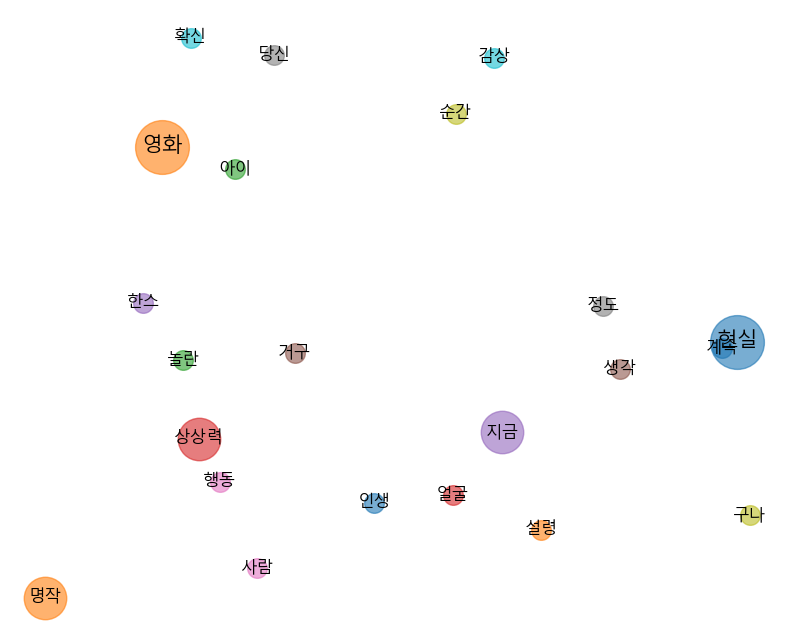

In [12]:
import matplotlib.pyplot as plt
from konlpy.tag import Okt
from collections import Counter
import random
import matplotlib.font_manager as fm
import numpy as np

# 리뷰 예시
reviews = [
    "현실이 설령 꿈이더라도, 이미 아이들의 얼굴을 보았다는것은.. 지금을 현실이라 받아들이고 살아가겠다는 것..",
    "생각이 행동을 만든다",
    "당신은 지금 이 순간이 현실이라 확신할 수 있나",
    "인생영화 놀란의 끝없는 상상력 속에서 한스짐머는 나를 쥐고 흔들었다",
    "재미있어요!",
    "영화가 이런거구나, 사람의 상상력이 이 정도구나 라고 느낀, 내게 영화감상을 계속 하게만든 명작 중의 명작",
]

# 텍스트 합치기
text = " ".join(reviews)

# 형태소 분석
okt = Okt()
words = okt.nouns(text)
words = [w for w in words if len(w) > 1]

# 단어 빈도 카운트 및 필터링
min_count = 1
count = Counter(words)
filtered = {k: v for k, v in count.items() if v >= min_count}

if not filtered:
    print("조건에 맞는 단어가 없습니다.")
else:
    words, freqs = zip(*filtered.items())
    
    # 크기 계산 (빈도의 제곱근 활용하여 편차 완화)
    sizes_raw = np.sqrt(freqs)
    
    # 크기 최소/최대 설정
    min_size, max_size = 200, 1500
    sizes = min_size + (sizes_raw - sizes_raw.min()) / (sizes_raw.max() - sizes_raw.min()) * (max_size - min_size)
    
    # 위치를 0.4~0.6 중앙 집중 분포
    x = [random.uniform(0.4, 0.6) for _ in words]
    y = [random.uniform(0.4, 0.6) for _ in words]
    
    plt.figure(figsize=(10, 8))
    plt.axis('off')
    
    # 한글 폰트 설정 (윈도우: 맑은 고딕)
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    fontprop = fm.FontProperties(fname=font_path)
    
    for (word, freq, size, xpos, ypos) in zip(words, freqs, sizes, x, y):
        plt.scatter(xpos, ypos, s=size, alpha=0.6)
        plt.text(xpos, ypos, word, fontsize=max(12, freq * 5), ha='center', va='center', fontproperties=fontprop)
    
    plt.show()

training was done. used memory 0.175 Gb
all cohesion probabilities was computed. # words = 0
all branching entropies was computed # words = 0
all accessor variety was computed # words = 0


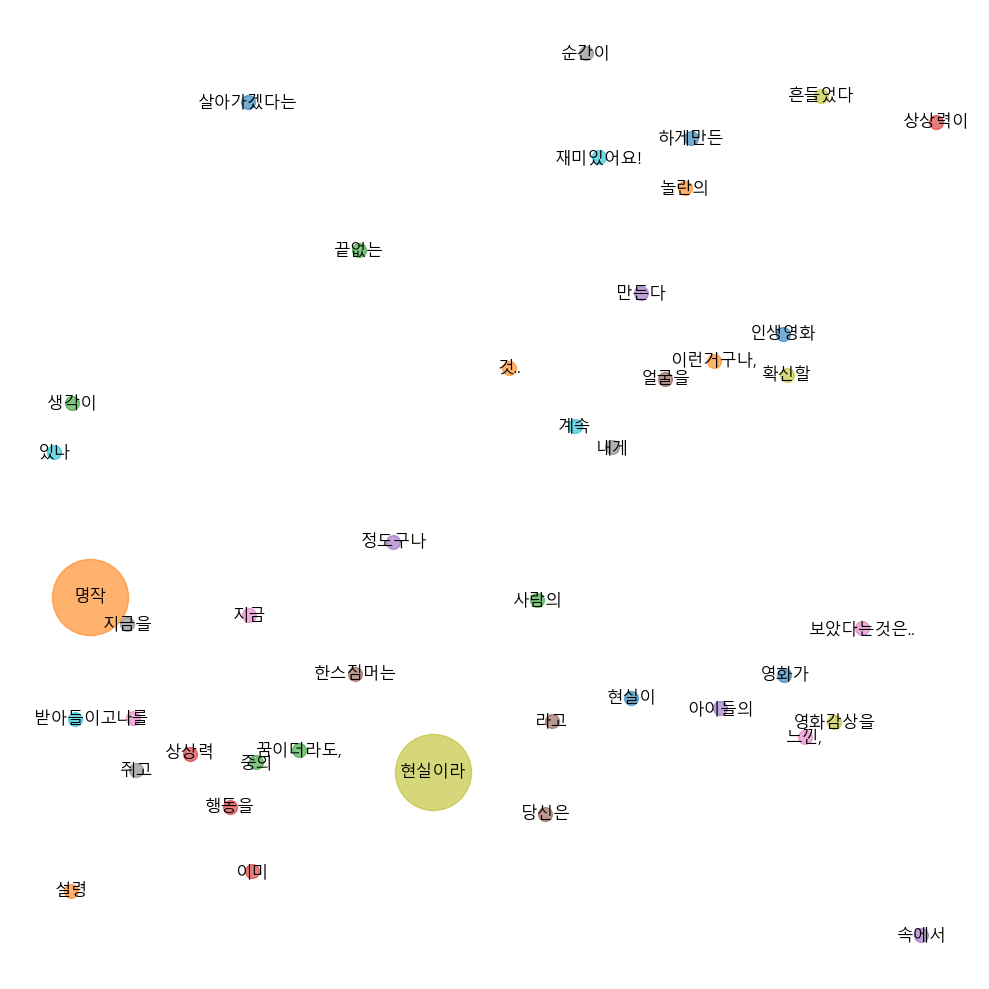

In [4]:
from soynlp.word import WordExtractor
from soynlp.tokenizer import LTokenizer
from collections import Counter
import matplotlib.pyplot as plt
import random
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (윈도우)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# 리뷰 예시
reviews = [
    "현실이 설령 꿈이더라도, 이미 아이들의 얼굴을 보았다는것은.. 지금을 현실이라 받아들이고 살아가겠다는 것..",
    "생각이 행동을 만든다",
    "당신은 지금 이 순간이 현실이라 확신할 수 있나",
    "인생영화 놀란의 끝없는 상상력 속에서 한스짐머는 나를 쥐고 흔들었다",
    "재미있어요!",
    "영화가 이런거구나, 사람의 상상력이 이 정도구나 라고 느낀, 내게 영화감상을 계속 하게만든 명작 중의 명작",
]

text = " ".join(reviews)

# 단어 점수 학습 및 추출
word_extractor = WordExtractor()
word_extractor.train(text)
word_scores = word_extractor.extract()

# Scores 객체 -> float 변환
word_scores_float = {word: float(score.cohesion_forward) for word, score in word_scores.items()}

# 토크나이저 생성
tokenizer = LTokenizer(scores=word_scores_float)

# 문장 토큰화
tokens = tokenizer.tokenize(text)

# 길이 2 이상 단어만 필터링 (필터링 후 빈 리스트 대비)
filtered_tokens = [t for t in tokens if len(t) > 1]

# 만약 필터링 후 빈 리스트면, 길이 조건 낮추기 (안정성 확보)
if not filtered_tokens:
    print("길이 2 이상 단어가 없어 필터링 조건 완화합니다.")
    filtered_tokens = [t for t in tokens if len(t) > 0]

# 단어 빈도 계산
count = Counter(filtered_tokens)

if not count:
    raise ValueError("단어 빈도 리스트가 비어있습니다. 텍스트 데이터나 필터 조건을 확인하세요.")

# 단어 리스트와 빈도 리스트 분리
words = list(count.keys())
frequencies = list(count.values())

# 크기 스케일링
min_size = 100
max_size = 3000
min_freq = min(frequencies)
max_freq = max(frequencies)

sizes = [
    min_size + (freq - min_freq) / (max_freq - min_freq) * (max_size - min_size) if max_freq > min_freq else min_size
    for freq in frequencies
]

# 랜덤 위치 배치 (중앙 집중 x, 단순 예제)
random.seed(42)
x = [random.uniform(0, 1) for _ in words]
y = [random.uniform(0, 1) for _ in words]

# 시각화
plt.figure(figsize=(10,10))
plt.axis('off')

for i, word in enumerate(words):
    plt.scatter(x[i], y[i], s=sizes[i], alpha=0.6)
    plt.text(x[i], y[i], word, ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('bubble_wordcloud.png')
plt.show()

In [5]:
!pip install mecab-python3

Defaulting to user installation because normal site-packages is not writeable


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import MeCab

dic_path = r'C:/ecab/mecab-ko-dic'
tagger = MeCab.Tagger(f'-d {dic_path}')
text = "나루토"
print(tagger.parse(text))

ImportError: DLL load failed while importing _MeCab: 지정된 모듈을 찾을 수 없습니다.

In [1]:
!pip install pororo wordcloud

Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of pororo to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of pororo to determine which version is compatible with other requirements. This could take a while.

The conflict is caused by:
    pororo 0.4.2 depends on torch==1.6.0
    pororo 0.4.1 depends on torch==1.6.0
    pororo 0.4.0 depends on torch==1.6.0
    pororo 0.3.5 depends on torch==1.6.0
    pororo 0.3.4 depends on torch==1.6.0
    pororo 0.3.3 depends on torch==1.6.0
    pororo 0.3.2 depends on torch==1.6.0
    pororo 0.3.1 depends on torch==1.6.0

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict



ERROR: Cannot install pororo==0.3.1, pororo==0.3.2, pororo==0.3.3, pororo==0.3.4, pororo==0.3.5, pororo==0.4.0, pororo==0.4.1 and pororo==0.4.2 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [5]:
import requests

url = "https://dapi.kakao.com/v1/analysis/morpheme"
headers = {
    "Authorization": "KakaoAK 98fb712a960e80a73dce67f1561dd4a6"
}
data = {
    "query": "오늘은 날씨가 정말 좋네요."
}

response = requests.post(url, headers=headers, data=data)
print(response.status_code)
print(response.json())

404
{'errorType': 'ResourceNotFound', 'message': "'POST /v1/analysis/morpheme' is not matched"}


현재 리뷰 개수: 10, 이전 리뷰 개수: 0
현재 리뷰 개수: 20, 이전 리뷰 개수: 10
현재 리뷰 개수: 30, 이전 리뷰 개수: 20
현재 리뷰 개수: 40, 이전 리뷰 개수: 30
현재 리뷰 개수: 50, 이전 리뷰 개수: 40
현재 리뷰 개수: 60, 이전 리뷰 개수: 50
현재 리뷰 개수: 70, 이전 리뷰 개수: 60
현재 리뷰 개수: 80, 이전 리뷰 개수: 70
현재 리뷰 개수: 90, 이전 리뷰 개수: 80
현재 리뷰 개수: 100, 이전 리뷰 개수: 90
현재 리뷰 개수: 110, 이전 리뷰 개수: 100
현재 리뷰 개수: 120, 이전 리뷰 개수: 110
현재 리뷰 개수: 130, 이전 리뷰 개수: 120
현재 리뷰 개수: 140, 이전 리뷰 개수: 130
현재 리뷰 개수: 150, 이전 리뷰 개수: 140
현재 리뷰 개수: 160, 이전 리뷰 개수: 150
현재 리뷰 개수: 170, 이전 리뷰 개수: 160
현재 리뷰 개수: 180, 이전 리뷰 개수: 170
현재 리뷰 개수: 190, 이전 리뷰 개수: 180
현재 리뷰 개수: 200, 이전 리뷰 개수: 190
현재 리뷰 개수: 210, 이전 리뷰 개수: 200
현재 리뷰 개수: 220, 이전 리뷰 개수: 210
현재 리뷰 개수: 230, 이전 리뷰 개수: 220
현재 리뷰 개수: 240, 이전 리뷰 개수: 230
현재 리뷰 개수: 250, 이전 리뷰 개수: 240
현재 리뷰 개수: 260, 이전 리뷰 개수: 250
현재 리뷰 개수: 270, 이전 리뷰 개수: 260
현재 리뷰 개수: 280, 이전 리뷰 개수: 270
현재 리뷰 개수: 290, 이전 리뷰 개수: 280
현재 리뷰 개수: 300, 이전 리뷰 개수: 290
현재 리뷰 개수: 310, 이전 리뷰 개수: 300
현재 리뷰 개수: 320, 이전 리뷰 개수: 310
현재 리뷰 개수: 330, 이전 리뷰 개수: 320
현재 리뷰 개수: 340, 이전 리뷰 개수: 330
현재 리뷰 개수: 350, 이전 리뷰 개수: 340
현재 리뷰

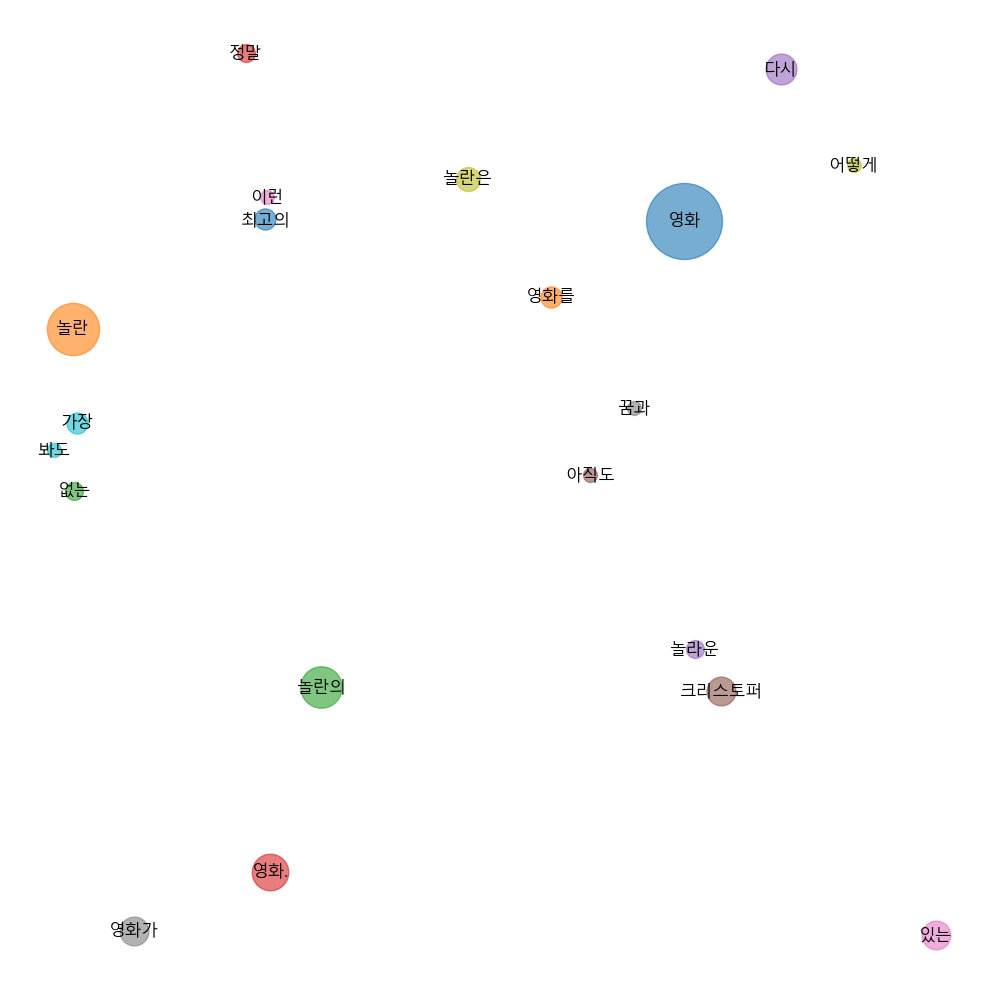

In [7]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time

from soynlp.word import WordExtractor
from soynlp.tokenizer import LTokenizer
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random

# 1. 크롬 드라이버 옵션 설정 및 리뷰 페이지 접속
options = Options()
# options.add_argument('--headless')  # 필요시 주석 해제
driver = webdriver.Chrome(options=options)
driver.get("https://m.kinolights.com/title/41164?tab=review")
time.sleep(2)

scrollable = driver.find_element(By.ID, "content__body")

prev_count = 0
no_change_count = 0
max_no_change = 3  # 변화 없을 때 최대 반복 횟수

while True:
    reviews = driver.find_elements(By.CSS_SELECTOR, 'section.review-list-section article')
    current_count = len(reviews)
    print(f"현재 리뷰 개수: {current_count}, 이전 리뷰 개수: {prev_count}")

    if current_count > prev_count:
        prev_count = current_count
        no_change_count = 0
    else:
        no_change_count += 1

    if no_change_count >= max_no_change:
        print(f"{max_no_change}번 연속 리뷰 수 변화 없음, 크롤링 종료")
        break

    if reviews:
        driver.execute_script("arguments[0].scrollIntoView(true);", reviews[-1])
    else:
        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight", scrollable)

    time.sleep(2)

html = driver.page_source
driver.quit()

# 2. BeautifulSoup로 리뷰 텍스트 추출
soup = BeautifulSoup(html, 'html.parser')
review_cards = soup.select('section.review-list-section article')

review_list = []
for card in review_cards:
    content = card.select_one('.contents__title')
    content_text = content.get_text(strip=True) if content else ''
    if content_text:
        review_list.append(content_text)

print(f"\n총 {len(review_list)}개의 리뷰를 수집했습니다.\n")

# 3. 텍스트 합치기
text = " ".join(review_list)

# 4. 단어 점수 학습 및 토큰화 (soynlp)
word_extractor = WordExtractor()
word_extractor.train(text)
word_scores = word_extractor.extract()

word_scores_float = {word: float(score.cohesion_forward) for word, score in word_scores.items()}
tokenizer = LTokenizer(scores=word_scores_float)
tokens = tokenizer.tokenize(text)
filtered_tokens = [t for t in tokens if len(t) > 1]

if not filtered_tokens:
    print("길이 2 이상 단어가 없어 필터링 조건 완화합니다.")
    filtered_tokens = [t for t in tokens if len(t) > 0]

# 5. 단어 빈도 계산 및 상위 20개 선택
count = Counter(filtered_tokens)
if not count:
    raise ValueError("단어 빈도 리스트가 비어있습니다. 텍스트 데이터나 필터 조건을 확인하세요.")

top_items = count.most_common(20)
words, frequencies = zip(*top_items)

# 6. 한글 폰트 설정 (윈도우용)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 7. 크기 스케일링
min_size = 100
max_size = 3000
min_freq = min(frequencies)
max_freq = max(frequencies)

sizes = [
    min_size + (freq - min_freq) / (max_freq - min_freq) * (max_size - min_size) if max_freq > min_freq else min_size
    for freq in frequencies
]

# 8. 랜덤 위치 배치
random.seed(42)
x = [random.uniform(0, 1) for _ in words]
y = [random.uniform(0, 1) for _ in words]

# 9. 시각화 및 저장
plt.figure(figsize=(10,10))
plt.axis('off')

for i, word in enumerate(words):
    plt.scatter(x[i], y[i], s=sizes[i], alpha=0.6)
    plt.text(x[i], y[i], word, ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('bubble_wordcloud_top20.png')
plt.show()

현재 리뷰 개수: 10, 이전 리뷰 개수: 0
현재 리뷰 개수: 20, 이전 리뷰 개수: 10
현재 리뷰 개수: 30, 이전 리뷰 개수: 20
현재 리뷰 개수: 40, 이전 리뷰 개수: 30
현재 리뷰 개수: 50, 이전 리뷰 개수: 40
현재 리뷰 개수: 60, 이전 리뷰 개수: 50
현재 리뷰 개수: 70, 이전 리뷰 개수: 60
현재 리뷰 개수: 80, 이전 리뷰 개수: 70
현재 리뷰 개수: 90, 이전 리뷰 개수: 80
현재 리뷰 개수: 100, 이전 리뷰 개수: 90
현재 리뷰 개수: 110, 이전 리뷰 개수: 100
현재 리뷰 개수: 120, 이전 리뷰 개수: 110
현재 리뷰 개수: 130, 이전 리뷰 개수: 120
현재 리뷰 개수: 140, 이전 리뷰 개수: 130
현재 리뷰 개수: 150, 이전 리뷰 개수: 140
현재 리뷰 개수: 160, 이전 리뷰 개수: 150
현재 리뷰 개수: 170, 이전 리뷰 개수: 160
현재 리뷰 개수: 180, 이전 리뷰 개수: 170
현재 리뷰 개수: 190, 이전 리뷰 개수: 180
현재 리뷰 개수: 200, 이전 리뷰 개수: 190
현재 리뷰 개수: 210, 이전 리뷰 개수: 200
현재 리뷰 개수: 220, 이전 리뷰 개수: 210
현재 리뷰 개수: 230, 이전 리뷰 개수: 220
현재 리뷰 개수: 240, 이전 리뷰 개수: 230
현재 리뷰 개수: 250, 이전 리뷰 개수: 240
현재 리뷰 개수: 260, 이전 리뷰 개수: 250
현재 리뷰 개수: 270, 이전 리뷰 개수: 260
현재 리뷰 개수: 280, 이전 리뷰 개수: 270
현재 리뷰 개수: 290, 이전 리뷰 개수: 280
현재 리뷰 개수: 300, 이전 리뷰 개수: 290
현재 리뷰 개수: 310, 이전 리뷰 개수: 300
현재 리뷰 개수: 320, 이전 리뷰 개수: 310
현재 리뷰 개수: 330, 이전 리뷰 개수: 320
현재 리뷰 개수: 340, 이전 리뷰 개수: 330
현재 리뷰 개수: 350, 이전 리뷰 개수: 340
현재 리뷰

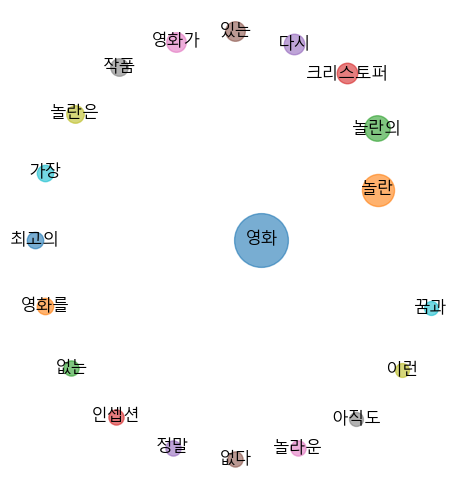

In [9]:
import re
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time

from soynlp.word import WordExtractor
from soynlp.tokenizer import LTokenizer
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 1. 크롬 드라이버 옵션 설정 및 리뷰 페이지 접속
options = Options()
# options.add_argument('--headless')  # 필요시 주석 해제
driver = webdriver.Chrome(options=options)
driver.get("https://m.kinolights.com/title/41164?tab=review")
time.sleep(2)

scrollable = driver.find_element(By.ID, "content__body")

prev_count = 0
no_change_count = 0
max_no_change = 3  # 변화 없을 때 최대 반복 횟수

while True:
    reviews = driver.find_elements(By.CSS_SELECTOR, 'section.review-list-section article')
    current_count = len(reviews)
    print(f"현재 리뷰 개수: {current_count}, 이전 리뷰 개수: {prev_count}")

    if current_count > prev_count:
        prev_count = current_count
        no_change_count = 0
    else:
        no_change_count += 1

    if no_change_count >= max_no_change:
        print(f"{max_no_change}번 연속 리뷰 수 변화 없음, 크롤링 종료")
        break

    if reviews:
        driver.execute_script("arguments[0].scrollIntoView(true);", reviews[-1])
    else:
        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight", scrollable)

    time.sleep(2)

html = driver.page_source
driver.quit()

# 2. BeautifulSoup로 리뷰 텍스트 추출
soup = BeautifulSoup(html, 'html.parser')
review_cards = soup.select('section.review-list-section article')

review_list = []
for card in review_cards:
    content = card.select_one('.contents__title')
    content_text = content.get_text(strip=True) if content else ''
    if content_text:
        review_list.append(content_text)

print(f"\n총 {len(review_list)}개의 리뷰를 수집했습니다.\n")

# 3. 텍스트 합치기 및 특수문자 제거
text = " ".join(review_list)
# 한글, 영어, 숫자, 공백만 남기기 (언더스코어 제거 위해 \w 대신 직접 지정)
text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', text)

# 4. 단어 점수 학습 및 토큰화 (soynlp)
word_extractor = WordExtractor()
word_extractor.train(text)
word_scores = word_extractor.extract()

word_scores_float = {word: float(score.cohesion_forward) for word, score in word_scores.items()}
tokenizer = LTokenizer(scores=word_scores_float)
tokens = tokenizer.tokenize(text)
filtered_tokens = [t for t in tokens if len(t) > 1]

if not filtered_tokens:
    print("길이 2 이상 단어가 없어 필터링 조건 완화합니다.")
    filtered_tokens = [t for t in tokens if len(t) > 0]

# 5. 단어 빈도 계산 및 상위 20개 선택
count = Counter(filtered_tokens)
if not count:
    raise ValueError("단어 빈도 리스트가 비어있습니다. 텍스트 데이터나 필터 조건을 확인하세요.")

top_items = count.most_common(20)
words, frequencies = zip(*top_items)

# 6. 한글 폰트 설정 (윈도우용)
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 7. 크기 스케일링
min_size = 100
max_size = 1500  # 이미지 크기 줄임에 맞게 버블 크기도 줄임
min_freq = min(frequencies)
max_freq = max(frequencies)

sizes = [
    min_size + (freq - min_freq) / (max_freq - min_freq) * (max_size - min_size) if max_freq > min_freq else min_size
    for freq in frequencies
]

# 8. 원형 중앙 집중 배치
n = len(words)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)

# 버블 크기에 반비례하는 반경 (크면 중심 가까이)
norm_sizes = [(s - min(sizes)) / (max(sizes) - min(sizes)) if max(sizes) > min(sizes) else 0.5 for s in sizes]
max_radius = 0.4
min_radius = 0.05
radii = [max_radius - norm_size * (max_radius - min_radius) for norm_size in norm_sizes]

x = [r * np.cos(a) + 0.5 for r, a in zip(radii, angles)]
y = [r * np.sin(a) + 0.5 for r, a in zip(radii, angles)]

# 9. 시각화 및 저장 (그림 크기도 작게)
plt.figure(figsize=(5, 5))
plt.axis('off')

for i, word in enumerate(words):
    plt.scatter(x[i], y[i], s=sizes[i], alpha=0.6)
    plt.text(x[i], y[i], word, ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('bubble_wordcloud_top20.png')
plt.show()

In [ ]:
import re
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time

from soynlp.word import WordExtractor
from soynlp.tokenizer import LTokenizer
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import random

# 1. 크롬 드라이버 옵션 설정 및 리뷰 페이지 접속
options = Options()
# options.add_argument('--headless')  # 필요시 주석 해제
driver = webdriver.Chrome(options=options)
driver.get("https://m.kinolights.com/title/41164?tab=review")
time.sleep(2)

scrollable = driver.find_element(By.ID, "content__body")

prev_count = 0
no_change_count = 0
max_no_change = 3

while True:
    reviews = driver.find_elements(By.CSS_SELECTOR, 'section.review-list-section article')
    current_count = len(reviews)
    print(f"현재 리뷰 개수: {current_count}, 이전 리뷰 개수: {prev_count}")

    if current_count > prev_count:
        prev_count = current_count
        no_change_count = 0
    else:
        no_change_count += 1

    if no_change_count >= max_no_change:
        break

    if reviews:
        driver.execute_script("arguments[0].scrollIntoView(true);", reviews[-1])
    else:
        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight", scrollable)

    time.sleep(2)

html = driver.page_source
driver.quit()

# 2. 리뷰 텍스트 추출
soup = BeautifulSoup(html, 'html.parser')
review_cards = soup.select('section.review-list-section article')

review_list = []
for card in review_cards:
    content = card.select_one('.contents__title')
    content_text = content.get_text(strip=True) if content else ''
    if content_text:
        review_list.append(content_text)

text = " ".join(review_list)
text = re.sub(r'[^\w\s가-힣]', '', text)

# 3. soynlp로 토크나이징
word_extractor = WordExtractor()
word_extractor.train(text)
word_scores = word_extractor.extract()

word_scores_float = {word: float(score.cohesion_forward) for word, score in word_scores.items()}
tokenizer = LTokenizer(scores=word_scores_float)
tokens = tokenizer.tokenize(text)
filtered_tokens = [t for t in tokens if len(t) > 1]

# 4. 단어 빈도 계산 및 상위 20개 추출
count = Counter(filtered_tokens)
top_items = count.most_common(20)
words, frequencies = zip(*top_items)

# 5. 시각화
font_path = 'C:/Windows/Fonts/malgun.ttf'  # 한글 폰트 설정
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 크기 설정
min_size = 1000
max_size = 5000
min_freq = min(frequencies)
max_freq = max(frequencies)

sizes = [
    min_size + (freq - min_freq) / (max_freq - min_freq) * (max_size - min_size)
    if max_freq > min_freq else min_size
    for freq in frequencies
]

# 랜덤 좌표
random.seed(42)
x = [random.uniform(0.1, 0.9) for _ in words]
y = [random.uniform(0.1, 0.9) for _ in words]

# 버블형 워드클라우드 그리기
plt.figure(figsize=(10, 10))
plt.axis('off')

for i, word in enumerate(words):
    plt.scatter(x[i], y[i], s=sizes[i], alpha=0.5, color=plt.cm.tab20(i % 20), edgecolors='black')
    plt.text(x[i], y[i], word, ha='center', va='center', fontsize=12, weight='bold', color='black')

plt.tight_layout()
plt.savefig('word_bubble_cloud.png', dpi=300)
plt.show()
